# From Subhalos to Observed Satellites
## Part 4 (optional) — Milky Way satellites from the DELVE Milky Way Census

Now let's do the same thing for the Milky Way, using the data from the [DELVE Milky Way Census](https://github.com/delve-survey/delve_mw_census) (from [Tan et al. 2025](https://arxiv.org/abs/2509.12313)).

In [1]:
%load_ext autoreload
%autoreload 2
    
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import io, reference as ref, selection as sl, plotting as pl

pl.use_tutorial_style()
SEED = 42
C_MOCK, C_TAN, C_OBS = "#C44E52", "#4C72B0", "k"

sims  = io.load_census_sims()          # injection-recovery: the selection function, unfitted
obs   = io.load_census_galaxies()      # the 51 satellites the census measures against
chain = io.load_census_chain()         # posterior of their empirical model
foot  = io.load_census_footprint()     # which sky was searched, and by which survey

print(f"injection-recovery : {len(sims):,} simulated satellites, "
      f"{sims.survey.value_counts().to_dict()}")
print(f"census sample      : {len(obs)} satellites, M_V = {obs.mv.min():.1f} to {obs.mv.max():.1f}")
print(f"posterior          : {chain.shape[0]:,} samples x {chain.shape[1]} parameters")
print(f"Tan+25 box         : {ref.TAN25_BOX}")

injection-recovery : 59,150 simulated satellites, {'des_y6': 32594, 'delve_dr3': 26556}
census sample      : 51 satellites, M_V = -18.1 to 0.0
posterior          : 4,000 samples x 6 parameters
Tan+25 box         : {'mv': (-20.0, 0.0), 'rhalf': (15.0, 3000.0), 'd_gc': (10.0, 300.0)}


---
# Section 5 — The completeness model

## 5.1 Inject, recover, count

Tan et al. injected tens of thousands of *fake* satellites, each with a chosen $M_V$, half-light radius and distance, painted into the **real**
DES Y6 and DELVE DR3 catalogs at real sky positions, recovered with the **real** search algorithms. `census_sims.parquet` is that experiment, one row per injection. It *is* the selection function. 

Text(0.035, 0.95, 'green: the published 50% contour\nstars: real dwarfs at these distances')

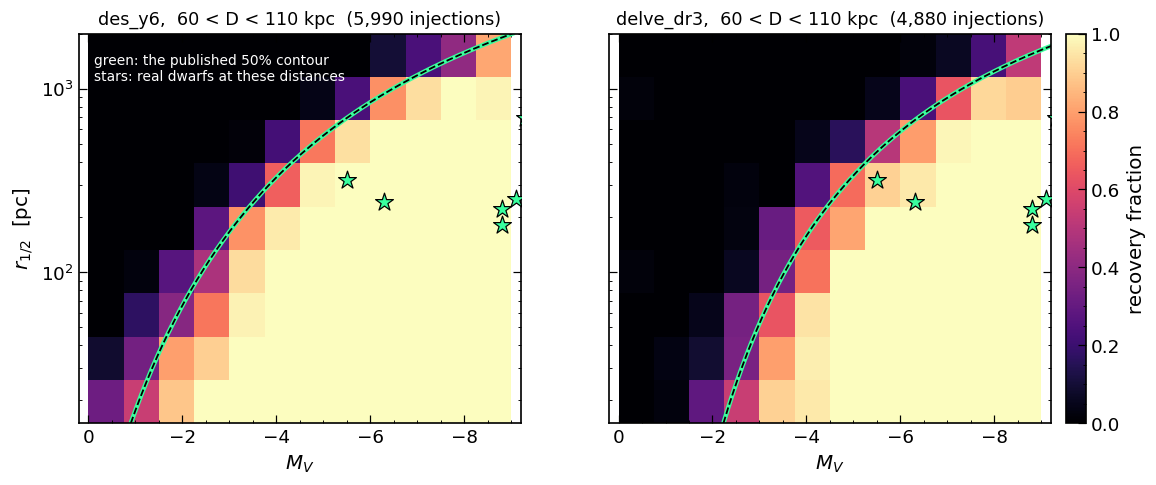

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), sharey=True, sharex=True)

D_LO, D_HI = 60.0, 110.0                      # one octave of distance
D_MID = np.sqrt(D_LO * D_HI)
mv_edges = np.linspace(-9.0, 0.0, 13)
lr_edges = np.linspace(np.log10(15.0), np.log10(2000.0), 10)
rh = np.logspace(np.log10(15.0), np.log10(2000.0), 200)

for ax, survey in zip(axes, ("des_y6", "delve_dr3")):
    s = sims[(sims.survey == survey) & (sims.d_helio > D_LO) & (sims.d_helio < D_HI)]
    i = np.digitize(s.mv.values, mv_edges) - 1
    j = np.digitize(np.log10(s.rhalf.values), lr_edges) - 1
    ok = ((i >= 0) & (i < len(mv_edges) - 1) & (j >= 0) & (j < len(lr_edges) - 1))

    n = np.zeros((len(lr_edges) - 1, len(mv_edges) - 1))
    k = np.zeros_like(n)
    np.add.at(n, (j[ok], i[ok]), 1.0)
    np.add.at(k, (j[ok], i[ok]), s.detected.values[ok].astype(float))
    frac = np.where(n >= 20, k / np.maximum(n, 1), np.nan)

    cmap = plt.get_cmap("magma").with_extremes(bad="0.75")
    im = ax.pcolormesh(mv_edges, 10 ** lr_edges, frac, cmap=cmap, vmin=0, vmax=1,
                       shading="flat", rasterized=True)
    ax.plot(ref.census_p50_mv(rh, D_MID, survey=survey), rh, color="#39FF9E", lw=3.0)
    ax.plot(ref.census_p50_mv(rh, D_MID, survey=survey), rh, color="k", lw=1.2, ls="--")

    known = ref.mw_dwarfs()
    near = known[(known.d_helio > D_LO) & (known.d_helio < D_HI)]
    ax.scatter(near.mv, near.rhalf, s=150, marker="*", color="#39FF9E", edgecolor="k",
               lw=0.8, zorder=4)

    ax.set(yscale="log", xlim=(0.2, -9.2), ylim=(15, 2000), xlabel=r"$M_V$")
    ax.set_title(f"{survey},  {D_LO:.0f} < D < {D_HI:.0f} kpc  ({len(s):,} injections)",
                 fontsize=11.5)

axes[0].set_ylabel(r"$r_{1/2}$  [pc]")
cb = fig.colorbar(im, ax=axes, pad=0.015, fraction=0.035)
cb.set_label("recovery fraction")
axes[0].text(0.035, 0.95, "green: the published 50% contour\nstars: real dwarfs at these distances",
             transform=axes[0].transAxes, va="top", fontsize=9, color="w")

### A simplified selection model

At fixed distance the 50% detection locus in the $(M_V, r_{1/2})$ plane can be parametrized as
$$M_{V,50}(r_{1/2}, D) = M_{V,0}(D) + \frac{A_0(D)}{\log_{10}r_{1/2} - \log_{10}r_{1/2,0}(D)},$$

three numbers per distance per survey (`reference.census_p50_mv`), softened into a probability

$$P_{\rm det} = \mathrm{logistic}\!\left(\frac{M_{V,50}(r_{1/2}, D) - M_V}{w}\right)$$

with $w = 0.32$ mag for DES Y6 and $0.38$ for DELVE DR3. Those widths are not ours: they are
fitted to the same injections plotted above, and they live in `reference.CENSUS_WIDTH`. The width
turns out to matter very little — anything between 0.2 and 1.2 mag moves a predicted count by
under 3% — because the population is steep and most satellites sit far from the contour on one
side or the other.

In [6]:
print("M_V at 50% detection, by survey, size and distance\n")
print(f"{'':11s}{'D (kpc)':>9}" + "".join(f"{f'r={r} pc':>11}" for r in (30, 100, 300, 1000)))
for survey, _ in ref.MW_CENSUS_FOOTPRINT:
    for d in (25, 100, 300):
        print(f"{survey if d == 25 else '':11s}{d:9d}"
              + "".join(f"{ref.census_p50_mv(float(r), float(d), survey):11.2f}"
                        for r in (30, 100, 300, 1000)))

M_V at 50% detection, by survey, size and distance

             D (kpc)    r=30 pc   r=100 pc   r=300 pc  r=1000 pc
des_y6            25       0.10      -1.73      -4.34      -9.51
                 100      -1.80      -2.73      -3.99      -6.30
                 300      -3.59      -4.24      -5.13      -6.76
delve_dr3         25      -0.96      -2.56      -5.06     -10.99
                 100      -3.10      -3.95      -5.11      -7.26
                 300      -4.59      -5.14      -5.89      -7.27
ps1_dr1           25      -2.40      -4.11      -6.63     -11.87
                 100      -4.31      -5.17      -6.38      -8.74
                 300      -5.95      -6.49      -7.25      -8.71


---
## 5.2 Where they looked

`io.load_census_footprint()` is the HEALPix masks showing the survey footprint. We need this to know which satellites are in the footprint from our mocks.

searched :   27,726 deg^2 = 67.2% of the sky
not      :   13,527 deg^2 = 32.8%  (mostly the Galactic plane)


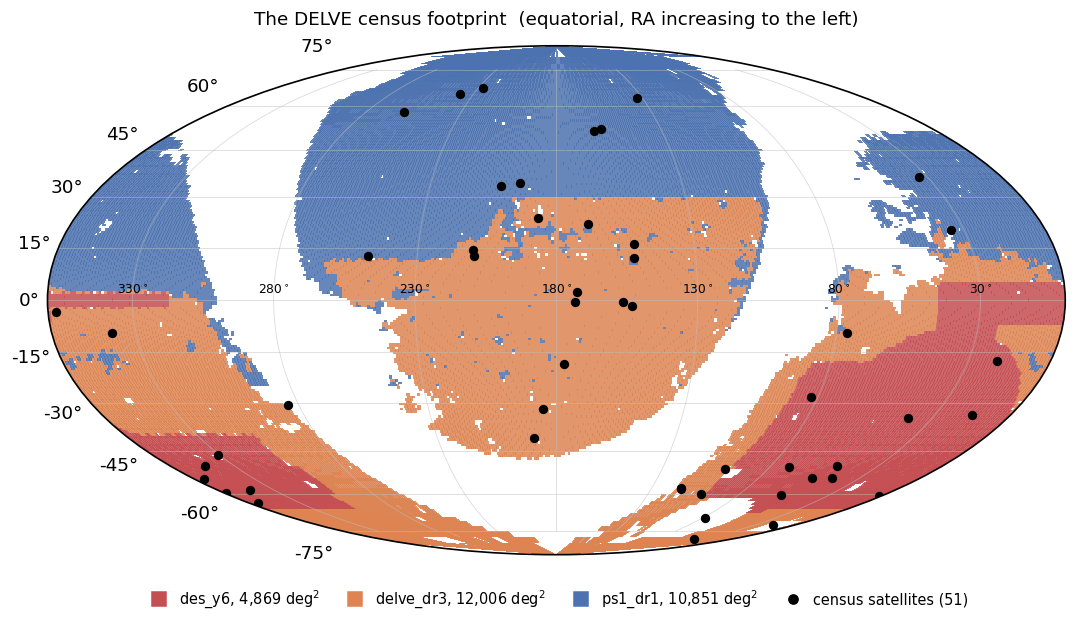

In [7]:
fig = plt.figure(figsize=(10.5, 5.6))
ax = fig.add_subplot(projection="mollweide")

areas = pl.plot_sky_coverage(ax, foot)
lon, lat = pl.sky_to_mollweide(obs.ra.values, obs.dec.values)
ax.scatter(lon, lat, s=26, color="k", zorder=5)
ax.set_title("The DELVE census footprint  (equatorial, RA increasing to the left)",
             fontsize=12, pad=14)

handles = [plt.Line2D([], [], marker="s", ls="", ms=9, color=pl.SURVEY_COLORS[s],
                      label=f"{s}, {areas[s]:,.0f} deg$^2$") for s in foot["surveys"]]
handles.append(plt.Line2D([], [], marker="o", ls="", ms=6, color="k",
                          label=f"census satellites ({len(obs)})"))
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.04),
          ncol=4, frameon=False, fontsize=9.5, columnspacing=1.4, handletextpad=0.4)
fig.tight_layout()

total = sum(areas.values())
print(f"searched : {total:8,.0f} deg^2 = {total/ref.SKY_AREA_DEG2:5.1%} of the sky")
print(f"not      : {ref.SKY_AREA_DEG2-total:8,.0f} deg^2 = {1-total/ref.SKY_AREA_DEG2:5.1%}"
      f"  (mostly the Galactic plane)")

However, let's assume that very bright satellites are completely known all over the sky (it's an okay assumption I guess), so we don't need to apply the footprint mask and selection function to them. The census is complete over the whole sky brighter than $M_V=-10$ (`reference.CENSUS_BRIGHT_ALL_SKY_MV`).

In [10]:
print("Number of observed satellites:", len(obs))

Number of observed satellites: 51



---
# Section 6 — Running the forward model

`selection.mock_observe` chains everything: occupation and the SHMR, then $M_V$ and size, then
an observer inside the halo, then the aperture, then $P_{\rm det}$. A survey is a dictionary, so
that everything about it is visible in one place.

In [12]:
import pprint
pprint.pprint(sl.MW_SURVEY, sort_dicts=False)

{'geometry': 'mw',
 'aperture': {'r_max_kpc': 300.0},
 'selection': {'kind': 'census',
               'width': None,
               'use_sky': True,
               'bright_all_sky_mv': -10},
 'requires_mv': True}


`use_sky=True` looks each satellite up in the real mask above rather than multiplying by the
footprint area fraction. That needs sky positions, and `place_mw_observer` supplies them — but
read what they mean. These SatGen runs have `fd = fb = 0`: **no disk and no bulge, so the halo
has no preferred plane**, and there is no physically meaningful place to put the Sun, let alone
a correct direction for the Galactic centre. Each host's sky is therefore rotated by its own
*random* rotation before being written down in RA and Dec.

In [16]:
hosts = io.load_hosts(data_dir="../data/", prefix="satgen_new_MW")
subs  = io.load_subhalos(data_dir="../data/", prefix="satgen_new_MW")

LGM_MW, DLGM = 12.0, 0.10                 # Milky-Way-mass hosts, +-0.10 dex
hh = hosts[np.abs(hosts.host_lgmvir - LGM_MW) <= DLGM + 1e-9]
sub_mw = subs[subs.host_id.isin(hh.host_id)]

FIDUCIAL = dict(
    occupation_params=dict(logM50=8.0, sigma_gal=0.4),
    shmr_params=dict(alpha=2.3, logM0=10.0, logMstar0=6.5, sigma_logMstar=0.3),
    observable_params=dict(
        mass_to_light=dict(mass_to_light_v=1.5, sigma_log_ml=0.0, 
                           mass_to_light_bright=1.0, mv_split=-10.0,),
        size=dict(size_norm=1500.0, size_slope=1.0, sigma_log_size=0.2, rvir_pivot=100.0)),
)

BOX = ref.TAN25_BOX
def in_tan25_box(df):
    # Cut a mock catalog to Tan+25's stated analysis box, exactly as they state it.
    return df[(df.mv >= BOX["mv"][0]) & (df.mv <= BOX["mv"][1])
              & (df.rhalf >= BOX["rhalf"][0]) & (df.rhalf <= BOX["rhalf"][1])
              & (df.r_3d >= BOX["d_gc"][0]) & (df.r_3d <= BOX["d_gc"][1])]


In [20]:
N_OBSERVER = 10 # different placements of the Sun in each mock Milky Way
frames = []
for r in range(N_OBSERVER):
    out = sl.mock_observe(sub_mw, survey_params=sl.MW_SURVEY,
                          rng=np.random.default_rng(SEED + r),
                          detected_only=False, **FIDUCIAL)
    out = in_tan25_box(out).copy()
    out["realization"] = r
    frames.append(out)

mock = pd.concat(frames, ignore_index=True)
KEY = ["realization", "host_id"]
n_real = mock.groupby(KEY).ngroups
n_intr = mock.groupby(KEY).size()
n_det  = mock.groupby(KEY).p_det.sum()

print(f"{n_real} mock Milky Ways ({len(hh)} hosts x {N_OBSERVER} observer placements)\n")
print(f"per mock Milky Way, inside the Tan+25 box:")
print(f"   intrinsic population : {n_intr.median():6.1f}  "
      f"[{n_intr.quantile(.16):.0f}, {n_intr.quantile(.84):.0f}]")
print(f"   detected             : {n_det.median():6.1f}  "
      f"[{n_det.quantile(.16):.1f}, {n_det.quantile(.84):.1f}]")
print(f"\nTan+25 completeness-corrected total : {np.median(chain[:,5]):.0f} "
      f"[{np.percentile(chain[:,5],16):.0f}, {np.percentile(chain[:,5],84):.0f}]")
print(f"comparison sample                   : {len(obs_cmp)}")

630 mock Milky Ways (63 hosts x 10 observer placements)

per mock Milky Way, inside the Tan+25 box:
   intrinsic population :  295.0  [252, 352]
   detected             :   53.8  [43.7, 65.5]

Tan+25 completeness-corrected total : 286 [228, 360]
comparison sample                   : 51


---
## 6.1 The predicted luminosity function

On the left the mock's **intrinsic** population against Tan+25's **completeness-corrected** model. On the right the mock's **detected** population against the
satellites the census actually has.

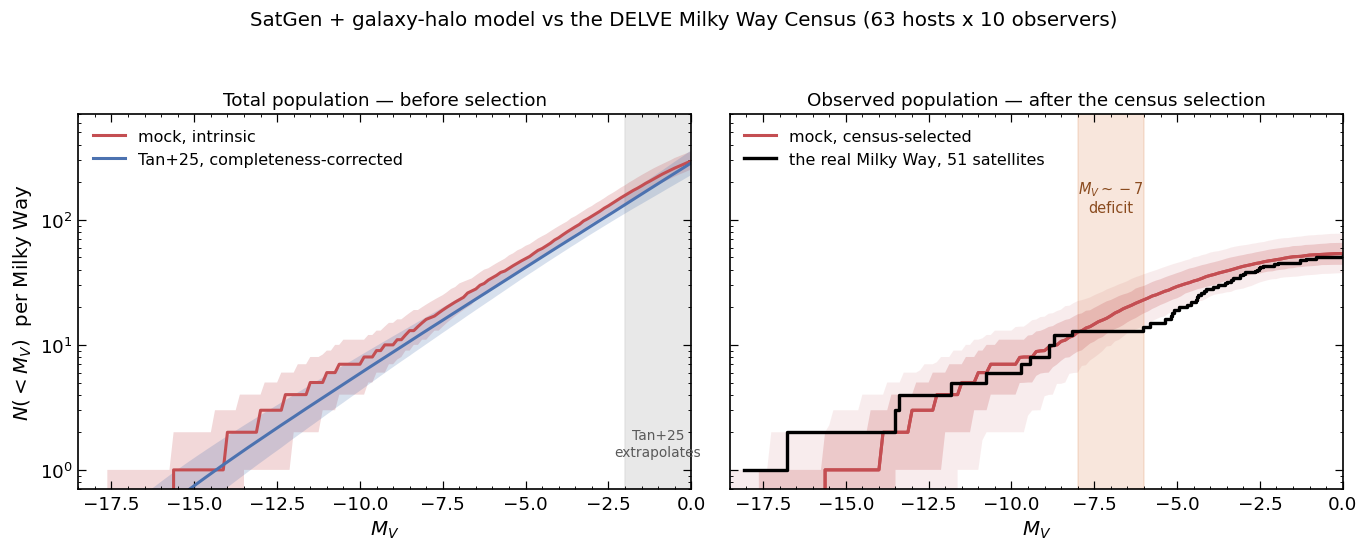

In [22]:
grid = np.linspace(-20.0, 0.0, 161)

def cumulative(col, grid, weight=None):
    # N(< grid) for every mock Milky Way, shape (n_real, len(grid)).
    out = np.zeros((n_real, len(grid)))
    for i, (_, g) in enumerate(mock.groupby(KEY, sort=True)):
        v = g[col].to_numpy()
        order = np.argsort(v)
        w = np.ones(len(g)) if weight is None else g[weight].to_numpy()
        cw = np.concatenate([[0.0], np.cumsum(w[order])])
        out[i] = cw[np.searchsorted(v[order], grid)]
    return out

cum_intr = cumulative("mv", grid)
cum_det  = cumulative("mv", grid, weight="p_det")
cum_tan  = ref.tan25_luminosity_function(grid, chain)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.1), sharey=True)

ax = axes[0]
pl.plot_band(ax, grid, cum_intr, color=C_MOCK, label="mock, intrinsic")
pl.plot_band(ax, grid, cum_tan, color=C_TAN, label="Tan+25, completeness-corrected")
ax.axvspan(-2, 0, color="0.85", alpha=0.6, zorder=0)
ax.text(-1.0, 1.3, "Tan+25\nextrapolates", fontsize=9, ha="center", color="0.35")
ax.set_title("Total population — before selection", fontsize=12)
ax.set_ylabel(r"$N(<M_V)$  per Milky Way")
ax.legend(loc="upper left")

ax = axes[1]
pl.plot_band(ax, grid, cum_det, color=C_MOCK, label="mock, census-selected", percentiles=(2.5, 50, 97.5), alpha=0.1)
pl.plot_band(ax, grid, cum_det, color=C_MOCK, percentiles=(16, 50, 84),)
ax.step(np.sort(obs.mv.values), np.arange(1, len(obs) + 1), where="post",
        color=C_OBS, lw=2.2, label=f"the real Milky Way, {len(obs)} satellites")
ax.axvspan(-8, -6, color="#DD8452", alpha=0.20, zorder=0)
ax.text(-7.0, 115, r"$M_V\sim-7$" + "\ndeficit", fontsize=9.5, ha="center", color="#8a4b1f")
ax.set_title("Observed population — after the census selection", fontsize=12)
ax.legend(loc="upper left")

for ax in axes:
    ax.set(yscale="log", xlim=(-18.5, 0), ylim=(0.7, 700), xlabel=r"$M_V$")
fig.suptitle(f"SatGen + galaxy-halo model vs the DELVE Milky Way Census "
             f"({len(hh)} hosts x {N_OBSERVER} observers)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])

From Tan+25:
> *"We also observe a deficit of galaxies with absolute magnitude $M_V \sim -7$ compared to the
> predictions of our empirical model. This feature has been noted by [Bose et al. 2018], who
> attribute it to a bimodality in the satellite population driven by the effects of
> reionization."*

---
## 6.3 The radial distribution

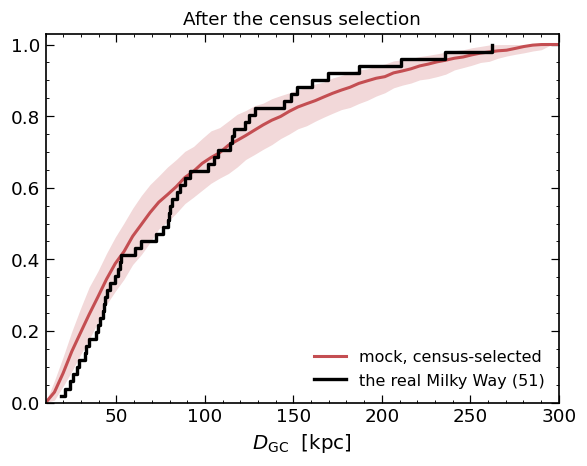

In [ ]:
r_grid = np.linspace(10.0, 300.0, 60)

def shape(counts):
    return counts / counts[:, -1:]          # normalize each realization to its own total

prof_intr = shape(cumulative("r_3d", r_grid))
prof_det  = shape(cumulative("r_3d", r_grid, weight="p_det"))
prof_tan  = shape(ref.tan25_radial_profile(r_grid, chain))

fig, ax = plt.subplots(figsize=(5.5, 4.4))

pl.plot_band(ax, r_grid, prof_det, color=C_MOCK, label="mock, census-selected")
d_sorted = np.sort(obs.d_gc.values)
ax.step(d_sorted, np.arange(1, len(d_sorted) + 1) / len(d_sorted), where="post",
        color=C_OBS, lw=2.2, label=f"the real Milky Way ({len(obs)})")
ax.set_title("After the census selection", fontsize=12)
ax.legend(loc="lower right")

ax.set(xlim=(10, 300), ylim=(0, 1.03), xlabel=r"$D_{\rm GC}$  [kpc]")
fig.tight_layout();